# 01 - Data Exploration

**Goal:** Understand the structure of Duolingo's notification dataset before implementing anything.

This notebook answers:
- What does each row represent?
- What are the "arms" (templates) of the bandit?
- How do eligibility and history work?
- What does the reward look like?
- What's the difference between train and test sets?

## Setup

We add the project root to `sys.path` so we can import from `src/`.

In [1]:
pip install seaborn


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

# --- LOW-MEMORY MODE ---
# Override USE_FULL_DATA so load_sample() respects n_rows
# instead of trying to load all 88M rows into RAM.
import src.data_loader as _dl
_dl.USE_FULL_DATA = False

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

from src.data_loader import load_sample, parse_history, parse_eligible_templates

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 80)

print("Ready!")

Ready!


---
## 1. Load Training Data (10K sample)

Each row = **one notification event**: Duolingo sent one push notification to one user at one moment. The data was collected under a **random policy** (templates chosen uniformly at random from eligible ones). This is critical — it means the observed reward rates are unbiased.

In [3]:
train_df = load_sample(n_rows=500_000, split="train")
print(f"\nShape: {train_df.shape}")
train_df.head(10)

[data_loader] Found 3 parquet files for 'train' split
[data_loader] === SAMPLE MODE ===
[data_loader] Loading 500,000 rows from 3 file(s)...
  Read part-00000-9b4bba6b-feac-44b1-a155-17c796835cca-c000.snappy.parquet: 1,980,100 rows so far
[data_loader] Raw data loaded: 500,000 rows in 9.5s
[data_loader] Memory (raw): 134.0 MB
[data_loader] Post-processing columns (parsing history & templates)...
[postprocess] Processing 500,000 rows in 1 batch(es) of 1,000,000...
  Batch 1/1: rows 0-500,000 done in 5.6s | Total: 500,000/500,000 (100%) | ETA: 0s
[postprocess] All 500,000 rows processed in 5.6s
[data_loader] Post-processing done in 5.6s
[data_loader] ✓ Final: 500,000 rows loaded in 15.2s total
[data_loader] Columns: ['datetime', 'ui_language', 'eligible_templates', 'history', 'selected_template', 'session_end_completed']
[data_loader] Memory (final): 177.0 MB

Shape: (500000, 6)


,datetime,ui_language,eligible_templates,history,selected_template,session_end_completed
0,0.153461,en,"[G, E, B, A, K, H, J, L, F, D]","[(A, 28.195648193359375), (C, 27.19352912902832), (C, 26.134174346923828), (...",B,0
1,2.827303,es,"[G, E, B, A, K, H, J, L, F, D]","[(A, 29.836181640625), (E, 28.835895538330078), (A, 28.03557586669922), (A, ...",A,1
2,2.792662,en,"[G, E, B, K, H, J, L, F, D]","[(G, 8.197543144226074), (D, 6.024779319763184), (F, 5.024777412414551), (B,...",J,1
3,4.904225,en,"[G, E, B, A, K, H, J, L, F, D]","[(B, 29.00238037109375), (F, 27.99148178100586), (G, 26.991456985473633), (D...",L,0
4,9.538715,en,"[K, H, G, E, B, J, L, F, D, A]","[(B, 27.971458435058594), (B, 23.97145652770996), (G, 20.97145652770996), (C...",B,1
5,9.763287,en,"[K, H, G, E, B, J, L, F, D, A]","[(B, 29.013214111328125), (E, 28.01321029663086), (B, 7.82887601852417), (E,...",F,0
6,9.301667,en,"[K, H, G, E, B, J, L, F, D, A]","[(C, 29.00682830810547), (C, 28.00682830810547), (E, 27.0068302154541), (E, ...",E,0
7,6.519630,en,"[G, E, B, K, H, J, L, F, D]","[(B, 29.046646118164062), (G, 28.041749954223633), (G, 26.048667907714844), ...",F,0
8,9.735660,en,"[K, H, G, E, B, J, L, F, D]","[(E, 29.99932861328125), (B, 29.004384994506836), (G, 27.996204376220703), (...",E,0
9,8.220833,en,"[G, E, B, A, K, H, J, L, F, D]","[(D, 5.13071870803833), (K, 4.0530877113342285), (J, 1.9947247505187988)]",G,0


### Save a 10K sample for quick access

We save a small 10K-row parquet file under `data/` so other notebooks or scripts can load it instantly without reading the full dataset every time.

We convert `history` and `eligible_templates` to JSON strings before saving because parquet can't serialize nested Python objects (lists of tuples) directly.

In [4]:
sample_10k = train_df.head(10_000).copy()

# Convert list columns to JSON strings so parquet can serialize them
sample_10k["eligible_templates"] = sample_10k["eligible_templates"].apply(json.dumps)
sample_10k["history"] = sample_10k["history"].apply(json.dumps)

sample_path = os.path.join("..", "data", "sample_10k.parquet")
sample_10k.to_parquet(sample_path, index=False)
print(f"Saved {len(sample_10k):,} rows to {sample_path}")
print(f"File size: {os.path.getsize(sample_path) / 1e6:.2f} MB")

Saved 10,000 rows to ../data/sample_10k.parquet
File size: 1.98 MB


---
## 2. Column-by-Column Breakdown

| Column | Type | Meaning |
|--------|------|---------|
| `datetime` | float | Days since dataset start (e.g., 3.75 = day 3, 6pm) |
| `ui_language` | string | User's app language (proxy for user segment) |
| `eligible_templates` | list of strings | Which templates **could** be sent right now ("sleeping arms") |
| `history` | list of (template, days_ago) | What templates this user received recently |
| `selected_template` | string | Which template was actually sent (A–L) |
| `session_end_completed` | 0 or 1 | **REWARD** — did user complete a lesson within 2 hours? |

In [5]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 6 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   datetime               500000 non-null  float64
 1   ui_language            500000 non-null  str    
 2   eligible_templates     500000 non-null  object 
 3   history                500000 non-null  object 
 4   selected_template      500000 non-null  str    
 5   session_end_completed  500000 non-null  int64  
dtypes: float64(1), int64(1), object(2), str(2)
memory usage: 24.3+ MB


In [6]:
train_df.describe()

,datetime,session_end_completed
count,500000.000000,500000.000000
mean,7.210206,0.179672
std,4.033943,0.383914
min,0.000023,0.000000
25%,3.644465,0.000000
50%,7.458501,0.000000
75%,10.651311,0.000000
max,13.999907,1.000000


---
## 3. The Arms: Notification Templates (A–L)

In bandit terminology, each **template is an arm**. The algorithm's job is to learn which arm to pull (which template to send) for each user at each moment.

Number of arms (templates): 11
Template labels: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'J', 'K', 'L']

Selection counts per template:
selected_template
A    21729
B    50865
C    19827
D    51012
E    50997
F    50895
G    50750
H    51040
J    50649
K    51481
L    50755
Name: count, dtype: int64


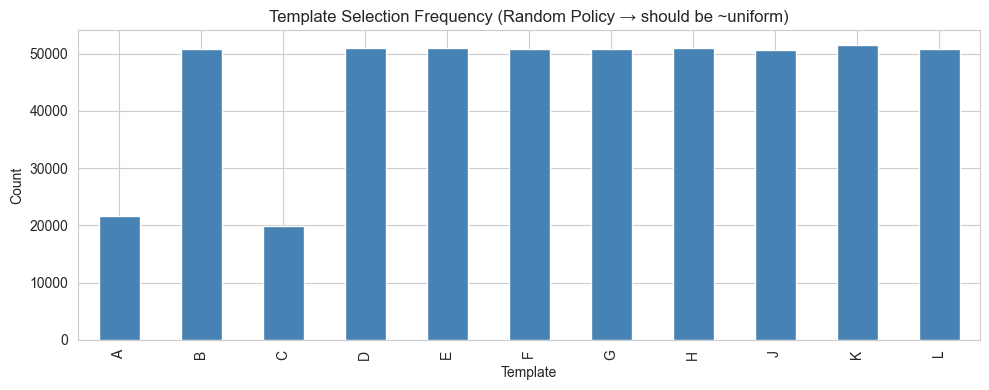

In [7]:
# How many unique templates (arms)?
templates = sorted(train_df["selected_template"].unique())
print(f"Number of arms (templates): {len(templates)}")
print(f"Template labels: {templates}")

# How often was each template selected? (should be ~uniform since random policy)
template_counts = train_df["selected_template"].value_counts().sort_index()
print(f"\nSelection counts per template:\n{template_counts}")

fig, ax = plt.subplots(figsize=(10, 4))
template_counts.plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Template Selection Frequency (Random Policy → should be ~uniform)")
ax.set_xlabel("Template")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

---
## 4. Sleeping Arms: Eligible Templates

Not all 12 templates are available at every moment. Some templates "sleep" — they're temporarily ineligible (e.g., a template just sent yesterday can't be sent again today). This is why the column `eligible_templates` varies per row.

First 5 rows — eligible_templates:
  Row 0: ['G', 'E', 'B', 'A', 'K', 'H', 'J', 'L', 'F', 'D']  (10 eligible out of 12)
  Row 1: ['G', 'E', 'B', 'A', 'K', 'H', 'J', 'L', 'F', 'D']  (10 eligible out of 12)
  Row 2: ['G', 'E', 'B', 'K', 'H', 'J', 'L', 'F', 'D']  (9 eligible out of 12)
  Row 3: ['G', 'E', 'B', 'A', 'K', 'H', 'J', 'L', 'F', 'D']  (10 eligible out of 12)
  Row 4: ['K', 'H', 'G', 'E', 'B', 'J', 'L', 'F', 'D', 'A']  (10 eligible out of 12)

Eligible set size stats:
count    500000.000000
mean          9.090526
std           1.759049
min           1.000000
25%           9.000000
50%           9.000000
75%          10.000000
max          10.000000
Name: eligible_templates, dtype: float64


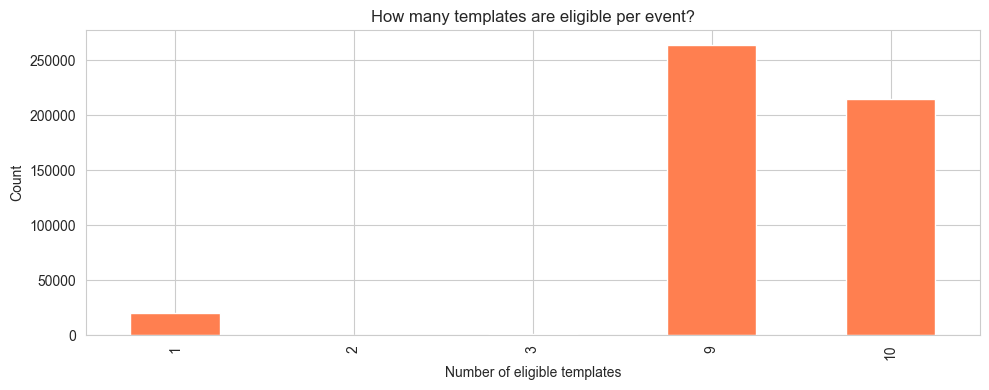

In [8]:
# Parse eligible_templates and look at a few examples
print("First 5 rows — eligible_templates:")
for i in range(5):
    raw = train_df["eligible_templates"].iloc[i]
    parsed = parse_eligible_templates(raw)
    print(f"  Row {i}: {parsed}  ({len(parsed)} eligible out of 12)")

# Distribution of how many templates are eligible per event
n_eligible = train_df["eligible_templates"].apply(lambda x: len(parse_eligible_templates(x)))
print(f"\nEligible set size stats:")
print(n_eligible.describe())

fig, ax = plt.subplots(figsize=(10, 4))
n_eligible.value_counts().sort_index().plot(kind="bar", ax=ax, color="coral", edgecolor="white")
ax.set_title("How many templates are eligible per event?")
ax.set_xlabel("Number of eligible templates")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

---
## 5. User History

Each row carries a `history` field: a list of `(template, days_ago)` tuples showing what notifications this user received recently. This is what the **recency penalty** layer uses — if template A was sent 0.5 days ago, it gets penalized to avoid notification fatigue.

In [9]:
# Show examples of history (already parsed by data_loader)
print("Examples of user history:")
shown = 0
for i in range(len(train_df)):
    h = train_df["history"].iloc[i]
    if isinstance(h, list) and len(h) > 0 and shown < 5:
        print(f"\n  Row {i}: {len(h)} past notifications")
        for template, days_ago in h[:5]:  # show up to 5 entries
            print(f"    Template '{template}' was sent {days_ago:.2f} days ago")
        shown += 1
    if shown >= 5:
        break

# How many users have history vs no history?
hist_lengths = train_df["history"].apply(lambda x: len(x) if isinstance(x, list) else 0)
print(f"\n--- History length stats ---")
print(f"Users with NO history:    {(hist_lengths == 0).sum():,} ({(hist_lengths == 0).mean()*100:.1f}%)")
print(f"Users with some history:  {(hist_lengths > 0).sum():,} ({(hist_lengths > 0).mean()*100:.1f}%)")
print(f"\nHistory length distribution:")
print(hist_lengths.describe())

Examples of user history:

  Row 0: 22 past notifications
    Template 'A' was sent 28.20 days ago
    Template 'C' was sent 27.19 days ago
    Template 'C' was sent 26.13 days ago
    Template 'B' was sent 25.13 days ago
    Template 'C' was sent 23.19 days ago

  Row 1: 24 past notifications
    Template 'A' was sent 29.84 days ago
    Template 'E' was sent 28.84 days ago
    Template 'A' was sent 28.04 days ago
    Template 'A' was sent 26.04 days ago
    Template 'E' was sent 25.04 days ago

  Row 2: 6 past notifications
    Template 'G' was sent 8.20 days ago
    Template 'D' was sent 6.02 days ago
    Template 'F' was sent 5.02 days ago
    Template 'B' was sent 4.02 days ago
    Template 'G' was sent 3.02 days ago

  Row 3: 20 past notifications
    Template 'B' was sent 29.00 days ago
    Template 'F' was sent 27.99 days ago
    Template 'G' was sent 26.99 days ago
    Template 'D' was sent 25.99 days ago
    Template 'F' was sent 24.99 days ago

  Row 4: 10 past notifications


---
## 6. Reward: `session_end_completed`

The reward is binary: **1** if the user completed a lesson within 2 hours of receiving the notification, **0** otherwise. This is what the bandit algorithm optimizes — pick the template that maximizes this rate.

Overall reward rate: 0.1797 (17.97%)
Rewarded events: 89,836 out of 500,000

Reward rate per template (sorted best → worst):
                   reward_rate  n_rewarded  n_total
selected_template                                  
C                     0.414082        8210    19827
A                     0.308390        6701    21729
J                     0.166874        8452    50649
G                     0.165872        8418    50750
K                     0.164138        8450    51481
L                     0.163018        8274    50755
D                     0.162707        8300    51012
F                     0.162550        8273    50895
B                     0.162155        8248    50865
H                     0.162010        8269    51040
E                     0.161598        8241    50997


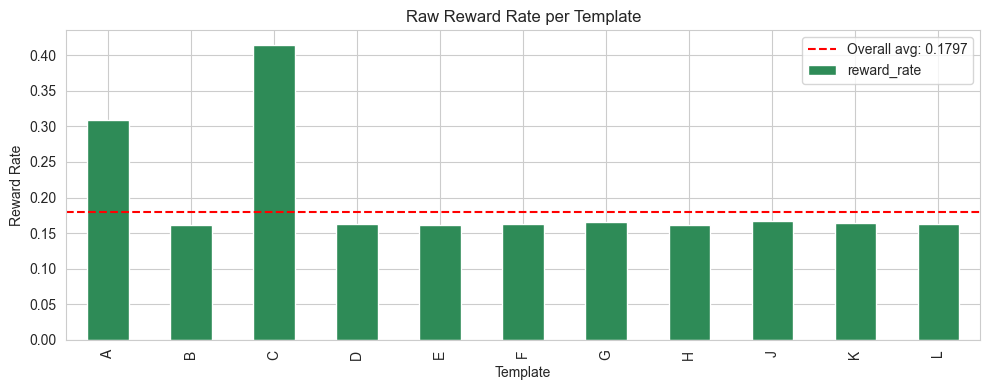

In [10]:
# Overall reward rate
reward_rate = train_df["session_end_completed"].mean()
total_rewarded = train_df["session_end_completed"].sum()
print(f"Overall reward rate: {reward_rate:.4f} ({reward_rate*100:.2f}%)")
print(f"Rewarded events: {total_rewarded:,} out of {len(train_df):,}")

# Reward rate per template
reward_by_template = train_df.groupby("selected_template")["session_end_completed"].agg(["mean", "sum", "count"])
reward_by_template.columns = ["reward_rate", "n_rewarded", "n_total"]
reward_by_template = reward_by_template.sort_values("reward_rate", ascending=False)
print(f"\nReward rate per template (sorted best → worst):")
print(reward_by_template.to_string())

fig, ax = plt.subplots(figsize=(10, 4))
reward_by_template["reward_rate"].sort_index().plot(kind="bar", ax=ax, color="seagreen", edgecolor="white")
ax.axhline(y=reward_rate, color="red", linestyle="--", label=f"Overall avg: {reward_rate:.4f}")
ax.set_title("Raw Reward Rate per Template")
ax.set_xlabel("Template")
ax.set_ylabel("Reward Rate")
ax.legend()
plt.tight_layout()
plt.show()

---
## 7. Users & Languages

There is **no user ID column** — each row is treated independently. The `ui_language` field is the closest proxy for user segmentation.

Number of unique languages: 23

Top 10 languages:
ui_language
en    216814
es    119783
pt     47383
ru     21468
fr     18606
de     15818
it      9095
vi      7004
ar      6403
pl      5914
Name: count, dtype: int64


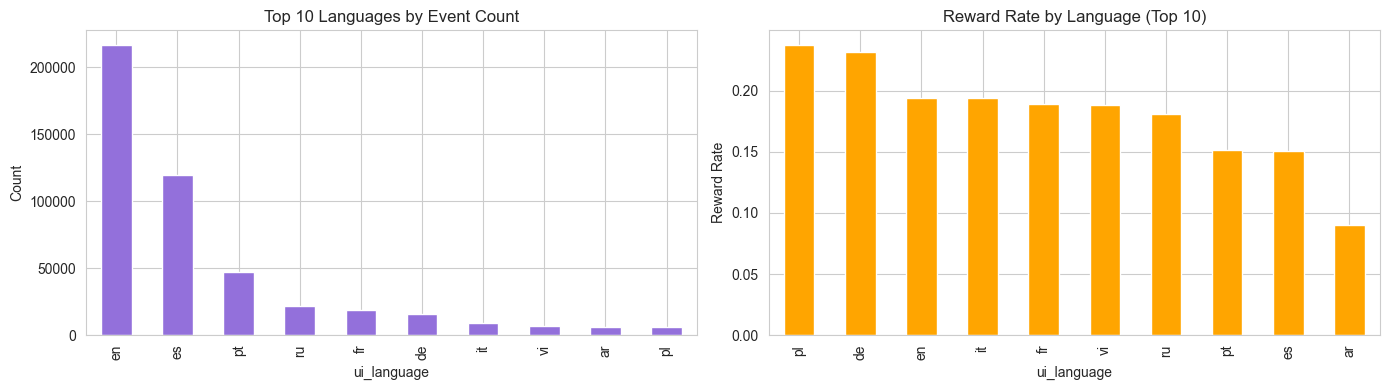

In [11]:
# Language distribution
lang_counts = train_df["ui_language"].value_counts()
print(f"Number of unique languages: {len(lang_counts)}")
print(f"\nTop 10 languages:")
print(lang_counts.head(10))

# Reward rate by language (top 10)
top_langs = lang_counts.head(10).index
reward_by_lang = train_df[train_df["ui_language"].isin(top_langs)].groupby("ui_language")["session_end_completed"].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

lang_counts.head(10).plot(kind="bar", ax=axes[0], color="mediumpurple", edgecolor="white")
axes[0].set_title("Top 10 Languages by Event Count")
axes[0].set_ylabel("Count")

reward_by_lang.plot(kind="bar", ax=axes[1], color="orange", edgecolor="white")
axes[1].set_title("Reward Rate by Language (Top 10)")
axes[1].set_ylabel("Reward Rate")

plt.tight_layout()
plt.show()

---
## 8. Time Distribution

`datetime` is a float representing days since the start of the dataset. Let's see the time span and how events are distributed over time.

Time range: day 0.00 to day 14.00
Span: 14.0 days


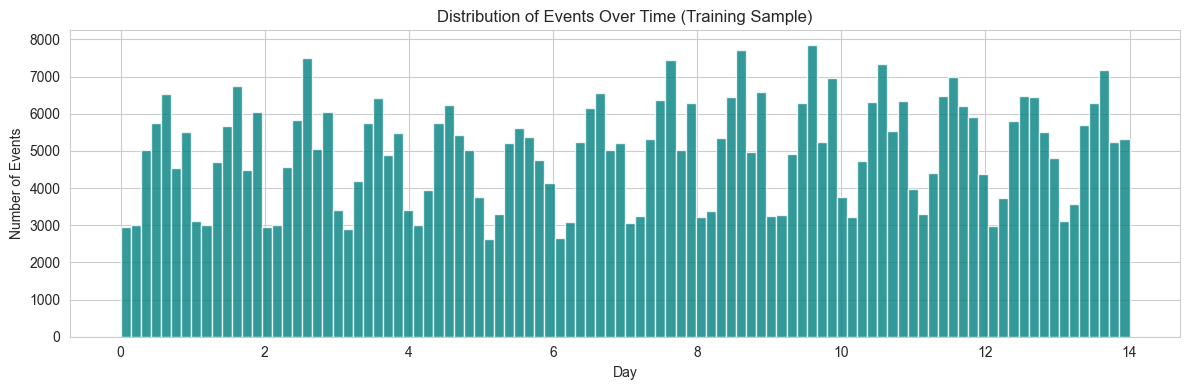

In [12]:
print(f"Time range: day {train_df['datetime'].min():.2f} to day {train_df['datetime'].max():.2f}")
print(f"Span: {train_df['datetime'].max() - train_df['datetime'].min():.1f} days")

fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(train_df["datetime"], bins=100, color="teal", edgecolor="white", alpha=0.8)
ax.set_title("Distribution of Events Over Time (Training Sample)")
ax.set_xlabel("Day")
ax.set_ylabel("Number of Events")
plt.tight_layout()
plt.show()

---
## 9. Test Data — Quick Comparison

The test set is used for **offline evaluation** via importance sampling. Let's load a sample and compare.

In [13]:
test_df = load_sample(n_rows=500_000, split="test")
print(f"\nTest shape: {test_df.shape}")
test_df.head(5)

[data_loader] Found 3 parquet files for 'test' split
[data_loader] === SAMPLE MODE ===
[data_loader] Loading 500,000 rows from 3 file(s)...
  Read part-00002-b6d6fc31-19ab-4361-8676-58414d2f5cad-c000.snappy.parquet: 1,966,945 rows so far
[data_loader] Raw data loaded: 500,000 rows in 10.0s
[data_loader] Memory (raw): 134.0 MB
[data_loader] Post-processing columns (parsing history & templates)...
[postprocess] Processing 500,000 rows in 1 batch(es) of 1,000,000...
  Batch 1/1: rows 0-500,000 done in 8.1s | Total: 500,000/500,000 (100%) | ETA: 0s
[postprocess] All 500,000 rows processed in 8.1s
[data_loader] Post-processing done in 8.1s
[data_loader] ✓ Final: 500,000 rows loaded in 18.2s total
[data_loader] Columns: ['datetime', 'ui_language', 'eligible_templates', 'history', 'selected_template', 'session_end_completed']
[data_loader] Memory (final): 177.8 MB

Test shape: (500000, 6)


,datetime,ui_language,eligible_templates,history,selected_template,session_end_completed
0,25.749306,en,"[K, H, G, E, B, J, L, F, D, A]","[(D, 29.036527633666992), (L, 28.0316162109375), (D, 27.031614303588867), (G...",G,0
1,17.323414,en,"[K, H, G, E, B, J, L, F, D]","[(E, 29.896867752075195), (B, 28.896873474121094), (D, 27.896547317504883), ...",H,0
2,29.586389,en,[C],"[(C, 28.684415817260742), (C, 27.689430236816406), (B, 26.730316162109375), ...",C,0
3,18.479190,en,"[K, H, G, E, B, J, L, F, D, A]","[(G, 29.89177894592285), (K, 28.73381233215332), (J, 27.733808517456055), (B...",H,0
4,15.145810,en,"[K, H, G, E, B, J, L, F, D]","[(E, 29.73885726928711), (F, 28.738859176635742), (D, 25.131359100341797), (...",H,0


In [14]:
# Side-by-side comparison
print("=" * 50)
print("TRAIN vs TEST comparison")
print("=" * 50)
print(f"{'Metric':<30} {'Train':>10} {'Test':>10}")
print("-" * 50)
print(f"{'Rows (sample)':<30} {len(train_df):>10,} {len(test_df):>10,}")
print(f"{'Full rows (approx)':<30} {'~87.7M':>10} {'~114.5M':>10}")
print(f"{'Time span (days)':<30} {train_df['datetime'].max()-train_df['datetime'].min():>10.1f} {test_df['datetime'].max()-test_df['datetime'].min():>10.1f}")
print(f"{'Reward rate':<30} {train_df['session_end_completed'].mean():>10.4f} {test_df['session_end_completed'].mean():>10.4f}")
print(f"{'Unique templates':<30} {train_df['selected_template'].nunique():>10} {test_df['selected_template'].nunique():>10}")
print(f"{'Unique languages':<30} {train_df['ui_language'].nunique():>10} {test_df['ui_language'].nunique():>10}")
print(f"{'Columns':<30} {train_df.shape[1]:>10} {test_df.shape[1]:>10}")

TRAIN vs TEST comparison
Metric                              Train       Test
--------------------------------------------------
Rows (sample)                     500,000    500,000
Full rows (approx)                 ~87.7M    ~114.5M
Time span (days)                     14.0       17.8
Reward rate                        0.1797     0.1668
Unique templates                       11         11
Unique languages                       23         23
Columns                                 6          6


---
## 10. Summary

Here's what we learned about the data:

| Fact | Value |
|------|-------|
| **Each row** | One notification sent to one user at one time |
| **Arms (templates)** | 12, labeled A through L |
| **Sleeping arms** | Not all templates eligible at every event — varies per row |
| **History** | List of (template, days_ago) tuples per event |
| **Reward** | Binary — did user complete a lesson within 2 hours? |
| **User ID** | None — rows are independent, no cross-row user tracking |
| **Collection policy** | Random (uniform over eligible templates) |
| **Train set** | ~87.7M rows, ~15 days |
| **Test set** | ~114.5M rows, ~19 days |

**Key insight:** Because the data was collected under a random policy, we can use **importance sampling** to estimate what any other policy would have achieved — without running a new A/B test.

**Next notebook:** `02_baseline_and_reward_rates.ipynb` — compute the random policy baseline and raw template reward rates.